In [2]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Step 2: Fetch data
stocks = ['RELIANCE.NS', 'TCS.NS', 'HDFCBANK.NS']
raw_data = yf.download(stocks, start='2024-05-01', end='2025-04-28')  # Adjusted end date

# Inspect raw data
print("Raw Data Shape:", raw_data.shape)
print("Raw Data Columns:", raw_data.columns)
print("First 5 Rows:\n", raw_data.head())
print("Missing Values:\n", raw_data.isna().sum())

# Check if data is empty
if raw_data.empty:
    raise ValueError("No data returned from yfinance. Check tickers, date range, or network connection.")

# Subset to Adj Close, with fallback to Close
try:
    data = raw_data['Adj Close']
except KeyError:
    print("Warning: 'Adj Close' not found. Using 'Close' instead.")
    data = raw_data['Close']
print("Data Shape:", data.shape)
print("First 5 Rows:\n", data.head())
print("Missing Values:\n", data.isna().sum())
data.to_csv('portfolio_data.csv')

# Step 3: Clean data
data = data.interpolate(method='linear')
data = data.fillna(method='ffill').fillna(method='bfill')
if (data <= 0).any().any():
    print("Warning: Invalid prices found.")
    data = data[data > 0]
print("Missing Values Post-Cleaning:\n", data.isna().sum())
returns = data.pct_change()
print("Returns Missing Values:\n", returns.isna().sum())

[*********************100%***********************]  3 of 3 completed

Raw Data Shape: (244, 15)
Raw Data Columns: MultiIndex([( 'Close', 'HDFCBANK.NS'),
            ( 'Close', 'RELIANCE.NS'),
            ( 'Close',      'TCS.NS'),
            (  'High', 'HDFCBANK.NS'),
            (  'High', 'RELIANCE.NS'),
            (  'High',      'TCS.NS'),
            (   'Low', 'HDFCBANK.NS'),
            (   'Low', 'RELIANCE.NS'),
            (   'Low',      'TCS.NS'),
            (  'Open', 'HDFCBANK.NS'),
            (  'Open', 'RELIANCE.NS'),
            (  'Open',      'TCS.NS'),
            ('Volume', 'HDFCBANK.NS'),
            ('Volume', 'RELIANCE.NS'),
            ('Volume',      'TCS.NS')],
           names=['Price', 'Ticker'])
First 5 Rows:
 Price             Close                                   High               \
Ticker      HDFCBANK.NS  RELIANCE.NS       TCS.NS  HDFCBANK.NS  RELIANCE.NS   
Date                                                                          
2024-05-02  1511.608276  1461.589478  3808.148682  1516.294287  1472.327934   
2


C:\Users\Yash\AppData\Local\Temp\ipykernel_2616\1433840150.py:34: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  data = data.fillna(method='ffill').fillna(method='bfill')


In [ ]:
#volatility , returns and sharpe ratio
weights = np.array([1/3, 1/3, 1/3])
portfolio_returns = returns.dot(weights)
valid_returns = portfolio_returns.dropna()
annualized_return = valid_returns.mean() * 252
print(f"Annualized Portfolio Return: {annualized_return:.4f}")

if len(valid_returns) < 2:
    raise ValueError("Insufficient returns for volatility")
daily_vol = valid_returns.std()
annualized_vol = daily_vol * np.sqrt(252)
print(f"Annualized Portfolio Volatility: {annualized_vol:.4f}")

risk_free_rate = 0.068
sharpe_ratio = (annualized_return - risk_free_rate) / annualized_vol
print(f"Sharpe Ratio: {sharpe_ratio:.4f}")

Annualized Portfolio Return: 0.0304
Annualized Portfolio Volatility: 0.1570
Sharpe Ratio: -0.2393


Plotting the data into visualisations

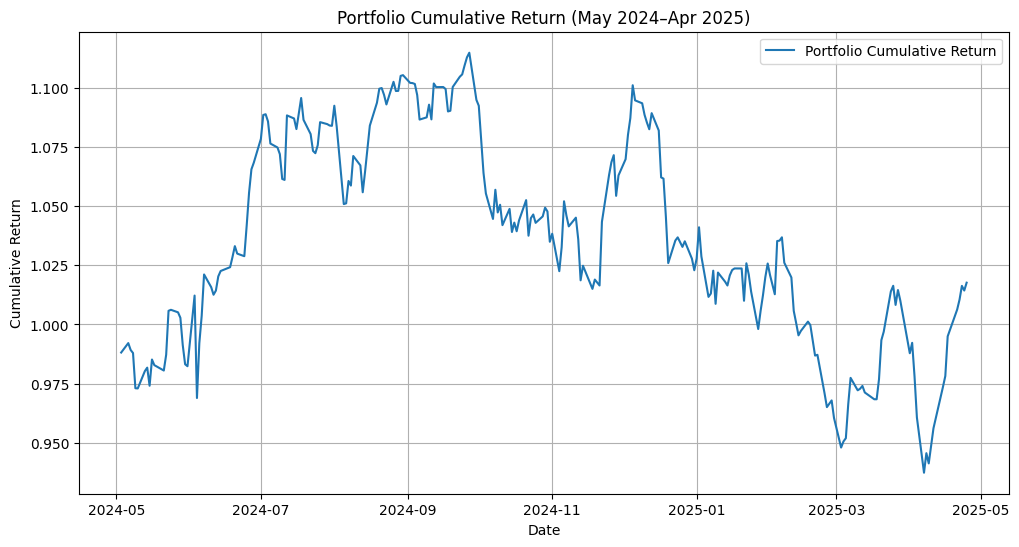

In [4]:
cumulative_returns = (1 + portfolio_returns).cumprod()
plt.figure(figsize=(12, 6))
plt.plot(cumulative_returns.index, cumulative_returns, label='Portfolio Cumulative Return')
plt.title('Portfolio Cumulative Return (May 2024–Apr 2025)')
plt.xlabel('Date')
plt.ylabel('Cumulative Return')
plt.legend()
plt.grid()
plt.savefig('portfolio_cumulative.png')
plt.show()

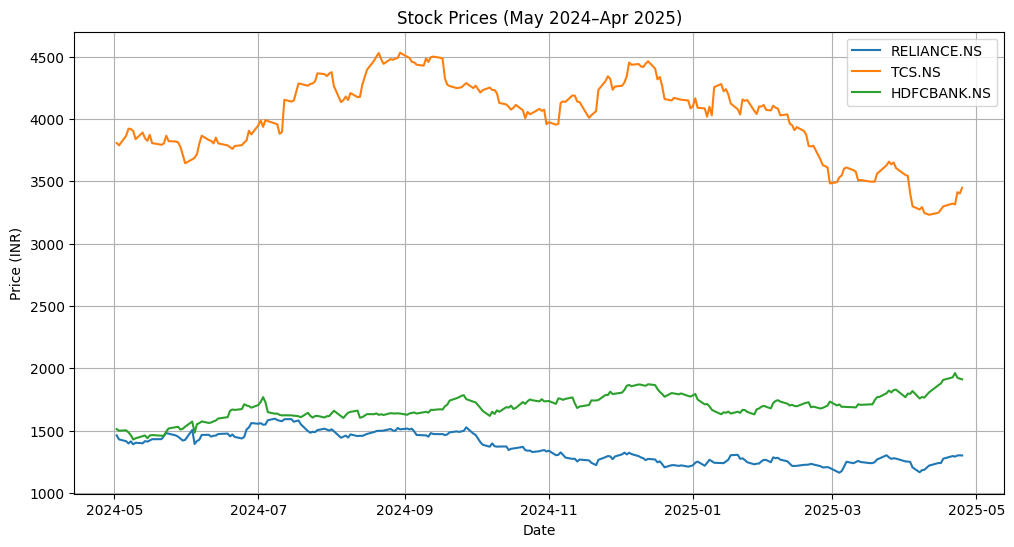

In [5]:
plt.figure(figsize=(12, 6))
for stock in stocks:
    plt.plot(data.index, data[stock], label=stock)
plt.title('Stock Prices (May 2024–Apr 2025)')
plt.xlabel('Date')
plt.ylabel('Price (INR)')
plt.legend()
plt.grid()
plt.savefig('stock_prices.png')
plt.show()

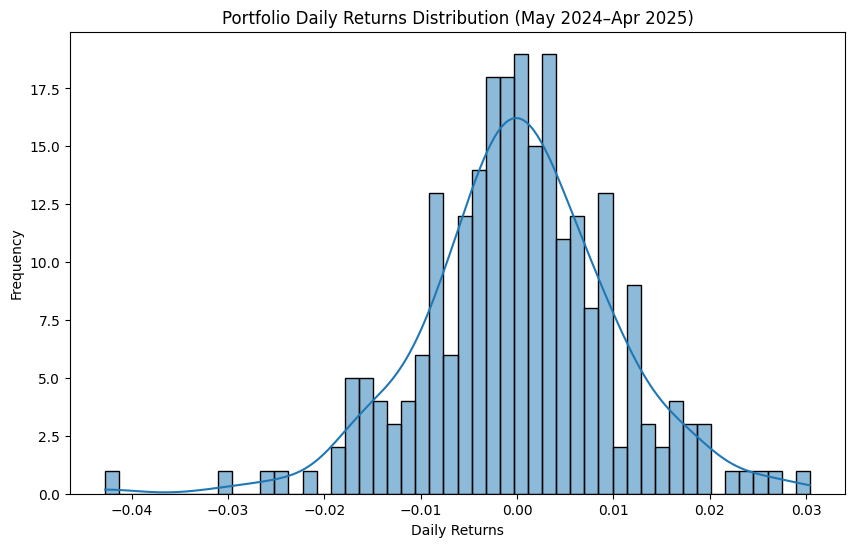

In [6]:
plt.figure(figsize=(10, 6))
sns.histplot(valid_returns, bins=50, kde=True)
plt.title('Portfolio Daily Returns Distribution (May 2024–Apr 2025)')
plt.xlabel('Daily Returns')
plt.ylabel('Frequency')
plt.savefig('returns_distribution.png')
plt.show()